In [9]:
import pandas as pd

data = pd.read_csv('lexicon_label.csv')
data.info()
data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7646 entries, 0 to 7645
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   normalisasi  7646 non-null   object
 1   Score        7646 non-null   int64 
 2   Sentiment    7646 non-null   object
dtypes: int64(1), object(2)
memory usage: 179.3+ KB


,normalisasi,Score,Sentiment
0,serius bertanya kalau tidak ada dpr semua oran...,-3,Negatif
1,menari di atas penderitaan rakyat,-2,Negatif
2,dunia akhirat gue tidak iklas byr pajak,-2,Negatif
3,tidak usah bayar pajak titikkkk,-3,Negatif
4,parah parah pejabat indonesiaa,-3,Negatif


In [10]:
def tokenize(text):
    tokens = text.split()
    return tokens

data['tokenize'] = data['normalisasi'].apply(tokenize)

data.head(5)

,normalisasi,Score,Sentiment,tokenize
0,serius bertanya kalau tidak ada dpr semua oran...,-3,Negatif,"[serius, bertanya, kalau, tidak, ada, dpr, sem..."
1,menari di atas penderitaan rakyat,-2,Negatif,"[menari, di, atas, penderitaan, rakyat]"
2,dunia akhirat gue tidak iklas byr pajak,-2,Negatif,"[dunia, akhirat, gue, tidak, iklas, byr, pajak]"
3,tidak usah bayar pajak titikkkk,-3,Negatif,"[tidak, usah, bayar, pajak, titikkkk]"
4,parah parah pejabat indonesiaa,-3,Negatif,"[parah, parah, pejabat, indonesiaa]"


In [11]:
## stopword removal
import re
import string
import nltk

from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sheva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

# Ubah hasil list jadi string
data['stopword removal'] = data['tokenize'].apply(
    lambda x: " ".join(remove_stopwords(x))
)

data.head(5)

,normalisasi,Score,Sentiment,tokenize,stopword removal
0,serius bertanya kalau tidak ada dpr semua oran...,-3,Negatif,"[serius, bertanya, kalau, tidak, ada, dpr, sem...",serius dpr orang hidup
1,menari di atas penderitaan rakyat,-2,Negatif,"[menari, di, atas, penderitaan, rakyat]",menari penderitaan rakyat
2,dunia akhirat gue tidak iklas byr pajak,-2,Negatif,"[dunia, akhirat, gue, tidak, iklas, byr, pajak]",dunia akhirat gue iklas byr pajak
3,tidak usah bayar pajak titikkkk,-3,Negatif,"[tidak, usah, bayar, pajak, titikkkk]",bayar pajak titikkkk
4,parah parah pejabat indonesiaa,-3,Negatif,"[parah, parah, pejabat, indonesiaa]",parah parah pejabat indonesiaa


In [13]:
hapus_kata = ['ya','sih','tau','biar', 'yg', 'ga', 'gak', 'ngga', 'nggak', 
              'udah', 'udh', 'emang', 'kayak', 'kaya', 'aja', 'doang', 
              'banget', 'bgt', 'juga', 'dong', 'loh', 'lho', 'nih', 'tuh', 
              'kak', 'pak', 'bu', 'bos', 'bang', 'abang', 'kak', 'mas',
              'mah', 'wkwk', 'wkwkwk', 'wkwkwkwk', 'haha', 'hehe', 'hihi',
              'huhu', 'xixi', 'anjir', 'anjir', 'buset', 'gilak', 'gila',
              'woii', 'woi', 'woy', 'wkwkw', 'hahaha', 'lah', 'sih', 'deh',
              'tapi', 'tp', 'klo', 'kalo', 'kalau', 'krn', 'karena',
              'sampe', 'sampe', 'gimana', 'gmn', 'jd', 'jadi', 'terus',
              'trs', 'udh', 'sudah', 'sdh', 'lg', 'lagi', 'pake', 'pakai',
              'hrs', 'harus', 'dgn', 'dengan', 'utk', 'untuk', 'dr', 'dari',
              'pd', 'pada', 'sm', 'sama', 'ke', 'di', 'yah', 'nah', 'kan',
              'pun', 'kok', 'saja', 'biar', 'kek', 'tuh', 'nih', 'deh',
              'cuma', 'hanya', 'iya', 'iyaa', 'iyaaa', 'gue', 'gw', 'lu',
              'lo', 'elu', 'lo', 'mereka', 'dia', 'ini', 'itu', 'sini', 'situ']

# hapus kata dari teks
data['stopword removal'] = data['stopword removal'].apply(
    lambda x: ' '.join([kata for kata in x.split() if kata not in hapus_kata]))

data['stopword removal'].str.contains('|'.join(hapus_kata)).sum()

np.int64(6466)

In [14]:
# --- IGNORE ---

In [15]:
data.to_csv('Hasil_Labelling_Data_3class.csv',encoding='utf8', index=False)

## WordCloud Kata Eksklusif per Kelas
Setiap kelas sentimen hanya menampilkan kata-kata yang **unik/khas** untuk kelas tersebut. Kata yang muncul di lebih dari satu kelas akan dihapus, sehingga WordCloud benar-benar mencerminkan ciri khas masing-masing sentimen.

In [16]:
import pandas as pd
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

data = pd.read_csv("Hasil_Labelling_Data_3class.csv")
data = pd.DataFrame(data[['stopword removal', 'Sentiment']])

# Gabungkan semua teks per sentimen
teks_netral = data[data['Sentiment'] == 'Netral']['stopword removal'].dropna().str.cat(sep=' ')
teks_negatif = data[data['Sentiment'] == 'Negatif']['stopword removal'].dropna().str.cat(sep=' ')
teks_positif = data[data['Sentiment'] == 'Positif']['stopword removal'].dropna().str.cat(sep=' ')

# Hitung frekuensi kata per kelas
freq_netral = Counter(teks_netral.split())
freq_negatif = Counter(teks_negatif.split())
freq_positif = Counter(teks_positif.split())

# Ambil SET kata per kelas
set_netral = set(freq_netral.keys())
set_negatif = set(freq_negatif.keys())
set_positif = set(freq_positif.keys())

# Cari kata EKSKLUSIF: kata yang HANYA muncul di 1 kelas
kata_eksklusif_netral = set_netral - set_negatif - set_positif
kata_eksklusif_negatif = set_negatif - set_netral - set_positif
kata_eksklusif_positif = set_positif - set_netral - set_negatif

print(f"Jumlah kata eksklusif Netral : {len(kata_eksklusif_netral)}")
print(f"Jumlah kata eksklusif Negatif: {len(kata_eksklusif_negatif)}")
print(f"Jumlah kata eksklusif Positif: {len(kata_eksklusif_positif)}")

# Buat dict frekuensi hanya untuk kata eksklusif
freq_eksklusif_netral = {k: v for k, v in freq_netral.items() if k in kata_eksklusif_netral}
freq_eksklusif_negatif = {k: v for k, v in freq_negatif.items() if k in kata_eksklusif_negatif}
freq_eksklusif_positif = {k: v for k, v in freq_positif.items() if k in kata_eksklusif_positif}

Jumlah kata eksklusif Netral : 1110
Jumlah kata eksklusif Negatif: 5351
Jumlah kata eksklusif Positif: 1066


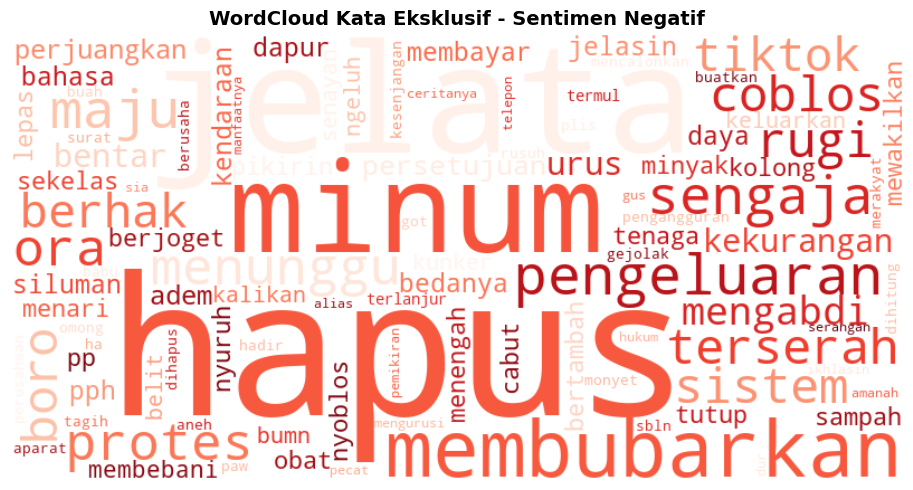

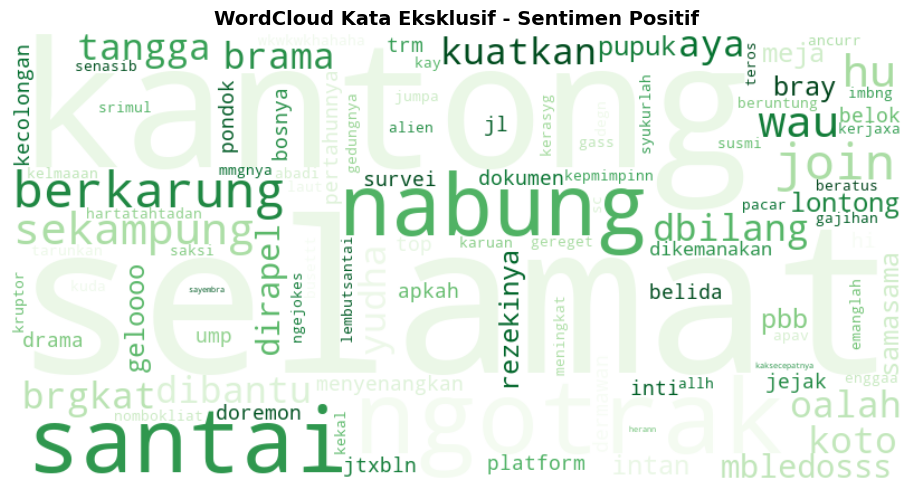

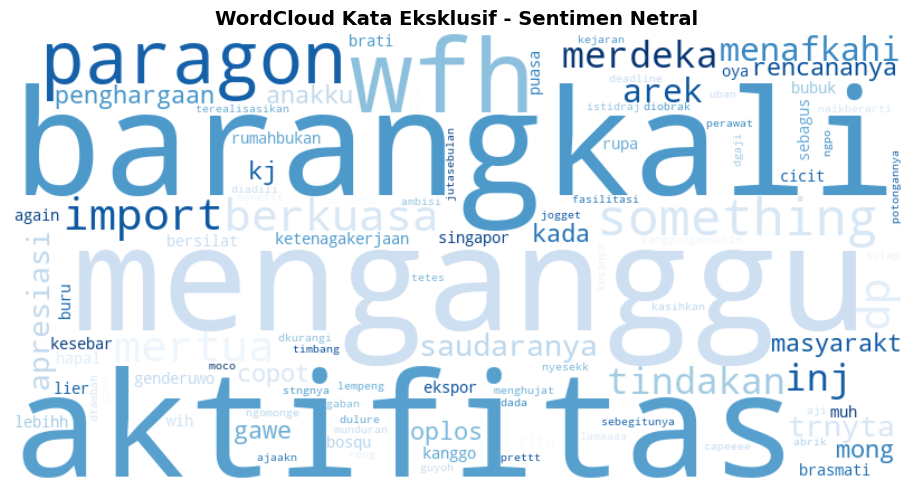

In [17]:
# Generate WordCloud dari kata eksklusif menggunakan generate_from_frequencies
def create_exclusive_wordcloud(freq_dict, title, bg_color='white', colormap='viridis'):
    if not freq_dict:
        print(f"Tidak ada kata eksklusif untuk {title}")
        return
    
    wc = WordCloud(
        width=800, height=400, 
        background_color=bg_color, 
        colormap=colormap,
        max_words=100,
        random_state=42
    ).generate_from_frequencies(freq_dict)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud Kata Eksklusif - Sentimen {title}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Tampilkan WordCloud eksklusif per kelas
create_exclusive_wordcloud(freq_eksklusif_negatif, "Negatif", bg_color='white', colormap='Reds')
create_exclusive_wordcloud(freq_eksklusif_positif, "Positif", bg_color='white', colormap='Greens')
create_exclusive_wordcloud(freq_eksklusif_netral, "Netral", bg_color='white', colormap='Blues')

In [18]:
# Tampilkan Top 10 kata eksklusif per kelas
def top_exclusive(freq_dict, label, n=10):
    top = sorted(freq_dict.items(), key=lambda x: x[1], reverse=True)[:n]
    df = pd.DataFrame(top, columns=['Kata', 'Frekuensi'])
    df.index = range(1, len(df)+1)
    print(f"\n--- Top {n} Kata Eksklusif Sentimen {label} ---")
    display(df)

top_exclusive(freq_eksklusif_negatif, "Negatif")
top_exclusive(freq_eksklusif_positif, "Positif")
top_exclusive(freq_eksklusif_netral, "Netral")


--- Top 10 Kata Eksklusif Sentimen Negatif ---


,Kata,Frekuensi
1,hapus,40
2,jelata,23
3,minum,15
4,membubarkan,14
5,pengeluaran,14
6,sengaja,13
7,maju,13
8,menunggu,12
9,ora,12
10,protes,12



--- Top 10 Kata Eksklusif Sentimen Positif ---


,Kata,Frekuensi
1,selamat,4
2,kantong,4
3,ngotrak,4
4,santai,3
5,nabung,3
6,berkarung,3
7,join,3
8,sekampung,3
9,hu,3
10,wau,3



--- Top 10 Kata Eksklusif Sentimen Netral ---


,Kata,Frekuensi
1,barangkali,4
2,menganggu,4
3,aktifitas,4
4,wfh,4
5,paragon,4
6,something,4
7,berkuasa,3
8,dp,3
9,import,3
10,mertua,3


In [19]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_Data_3class.csv")
data.info()
data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7646 entries, 0 to 7645
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   normalisasi       7646 non-null   object
 1   Score             7646 non-null   int64 
 2   Sentiment         7646 non-null   object
 3   tokenize          7646 non-null   object
 4   stopword removal  7599 non-null   object
dtypes: int64(1), object(4)
memory usage: 298.8+ KB


,normalisasi,Score,Sentiment,tokenize,stopword removal
0,serius bertanya kalau tidak ada dpr semua oran...,-3,Negatif,"['serius', 'bertanya', 'kalau', 'tidak', 'ada'...",serius dpr orang hidup
1,menari di atas penderitaan rakyat,-2,Negatif,"['menari', 'di', 'atas', 'penderitaan', 'rakyat']",menari penderitaan rakyat
2,dunia akhirat gue tidak iklas byr pajak,-2,Negatif,"['dunia', 'akhirat', 'gue', 'tidak', 'iklas', ...",dunia akhirat iklas byr pajak
3,tidak usah bayar pajak titikkkk,-3,Negatif,"['tidak', 'usah', 'bayar', 'pajak', 'titikkkk']",bayar pajak titikkkk
4,parah parah pejabat indonesiaa,-3,Negatif,"['parah', 'parah', 'pejabat', 'indonesiaa']",parah parah pejabat indonesiaa


In [20]:
data = pd.DataFrame(data[['stopword removal','Sentiment']])
data.head(5)

,stopword removal,Sentiment
0,serius dpr orang hidup,Negatif
1,menari penderitaan rakyat,Negatif
2,dunia akhirat iklas byr pajak,Negatif
3,bayar pajak titikkkk,Negatif
4,parah parah pejabat indonesiaa,Negatif


In [21]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Pisahkan dataset berdasarkan sentimen
sentimen_Neutral = data[data['Sentiment'] == 'Netral']['stopword removal'].str.cat(sep=' ')
sentimen_Negative = data[data['Sentiment'] == 'Negatif']['stopword removal'].str.cat(sep=' ')
sentimen_Positive = data[data['Sentiment'] == 'Positif']['stopword removal'].str.cat(sep=' ')

# Buat stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update([
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh','jokowi'])

# Buat wordcloud untuk masing-masing sentimen
wordcloud_neutral = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(sentimen_Neutral)
wordcloud_negative = WordCloud(width=800, height=400, background_color='black', colormap='Reds', stopwords=stopwords).generate(sentimen_Negative)
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', colormap='Greens', stopwords=stopwords).generate(sentimen_Positive)

# Fungsi untuk membuat dan menampilkan WordCloud
def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()


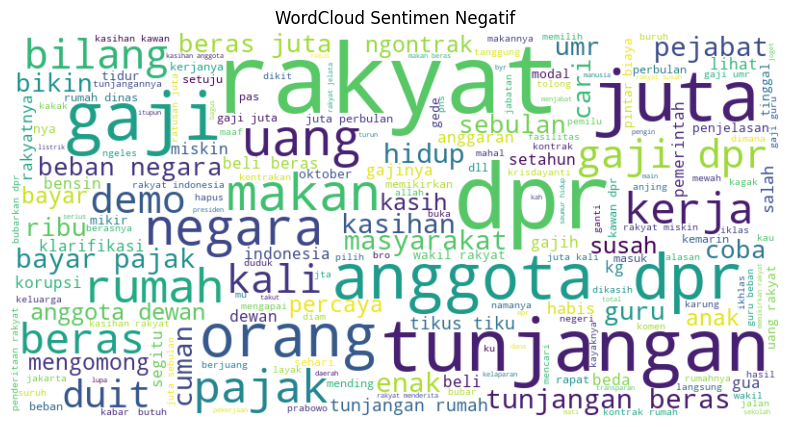

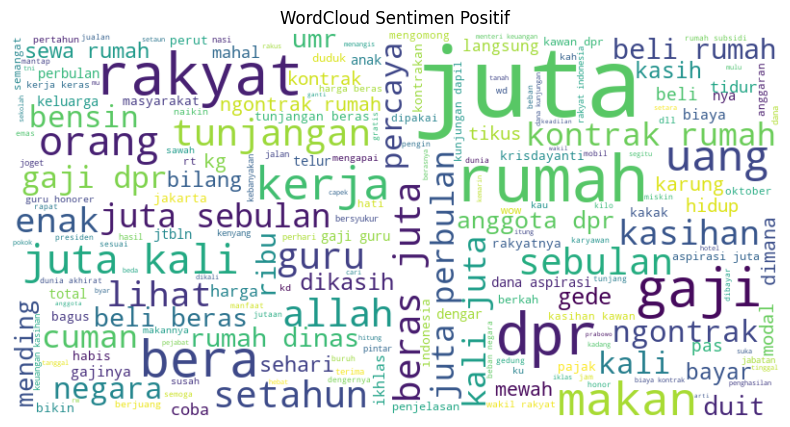

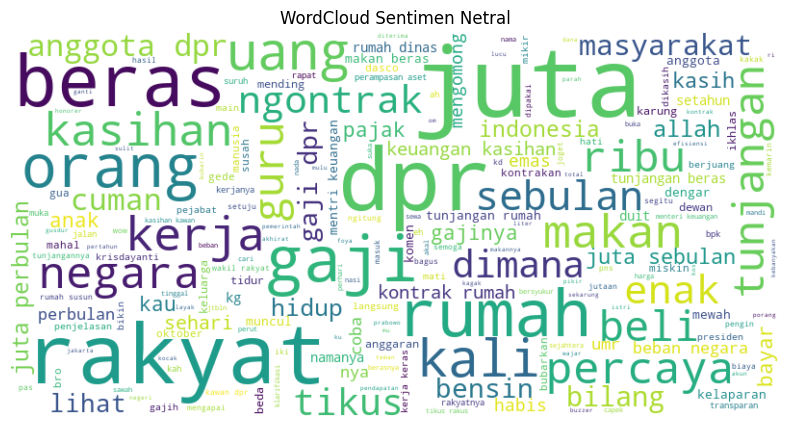

In [22]:
# Membuat WordCloud untuk sentimen Negatif
create_wordcloud(sentimen_Negative, 'WordCloud Sentimen Negatif')

# Membuat WordCloud untuk sentimen Positif
create_wordcloud(sentimen_Positive, 'WordCloud Sentimen Positif')

# Membuat WordCloud untuk sentimen Netral
create_wordcloud(sentimen_Neutral, 'WordCloud Sentimen Netral')

## Ngram Kata

In [23]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_Data_3class.csv")
data.info()
data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7646 entries, 0 to 7645
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   normalisasi       7646 non-null   object
 1   Score             7646 non-null   int64 
 2   Sentiment         7646 non-null   object
 3   tokenize          7646 non-null   object
 4   stopword removal  7599 non-null   object
dtypes: int64(1), object(4)
memory usage: 298.8+ KB


,normalisasi,Score,Sentiment,tokenize,stopword removal
0,serius bertanya kalau tidak ada dpr semua oran...,-3,Negatif,"['serius', 'bertanya', 'kalau', 'tidak', 'ada'...",serius dpr orang hidup
1,menari di atas penderitaan rakyat,-2,Negatif,"['menari', 'di', 'atas', 'penderitaan', 'rakyat']",menari penderitaan rakyat
2,dunia akhirat gue tidak iklas byr pajak,-2,Negatif,"['dunia', 'akhirat', 'gue', 'tidak', 'iklas', ...",dunia akhirat iklas byr pajak
3,tidak usah bayar pajak titikkkk,-3,Negatif,"['tidak', 'usah', 'bayar', 'pajak', 'titikkkk']",bayar pajak titikkkk
4,parah parah pejabat indonesiaa,-3,Negatif,"['parah', 'parah', 'pejabat', 'indonesiaa']",parah parah pejabat indonesiaa


In [24]:
data = pd.DataFrame(data[['stopword removal','Sentiment']])
data.head(5)

,stopword removal,Sentiment
0,serius dpr orang hidup,Negatif
1,menari penderitaan rakyat,Negatif
2,dunia akhirat iklas byr pajak,Negatif
3,bayar pajak titikkkk,Negatif
4,parah parah pejabat indonesiaa,Negatif


In [25]:
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# Stopwords tambahan (bisa disesuaikan)
custom_stopwords = list(ENGLISH_STOP_WORDS) + ['https', 'co', 'RT', '...', 'amp', 'lu', 'deh']

# Fungsi buat ambil n-gram
def get_top_ngrams(corpus, n=2, top_k=5, stopwords=None):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=stopwords).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Fungsi buat plot gabungan bigram dari 3 kelas sentimen
def plot_bigrams_combined(corpora, labels, colors, stopwords=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, corpus, label, color in zip(axes, corpora, labels, colors):
        top_ngrams = get_top_ngrams(corpus, n=2, top_k=5, stopwords=stopwords)
        if not top_ngrams:
            ax.set_title(f"Top 5 Bigram - Sentimen {label}")
            ax.text(0.5, 0.5, 'Tidak ada bigram', ha='center', va='center')
            continue

        ngrams, counts = zip(*top_ngrams)
        bars = ax.barh(ngrams, counts, color=color)
        ax.invert_yaxis()
        ax.set_title(f"Top 5 Bigram - Sentimen {label}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Jumlah Kemunculan", fontsize=11)

        for bar, num in zip(bars, counts):
            ax.text(num + 0.01, bar.get_y() + bar.get_height()/2,
                    str(num), va='center', fontsize=11, color='black')

    plt.tight_layout()
    plt.savefig('img/bigram_combined.png', dpi=300, bbox_inches='tight')
    plt.show()

# Ambil data per sentimen
corpus_neg = data[data['Sentiment'] == 'Negatif']['stopword removal'].astype(str).tolist()
corpus_neu = data[data['Sentiment'] == 'Netral']['stopword removal'].astype(str).tolist()
corpus_pos = data[data['Sentiment'] == 'Positif']['stopword removal'].astype(str).tolist()

d:\Data\Kuliah\Semester 7\Skripsi\tiktok-indobert\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['rt'] not in stop_words.
  warnings.warn(


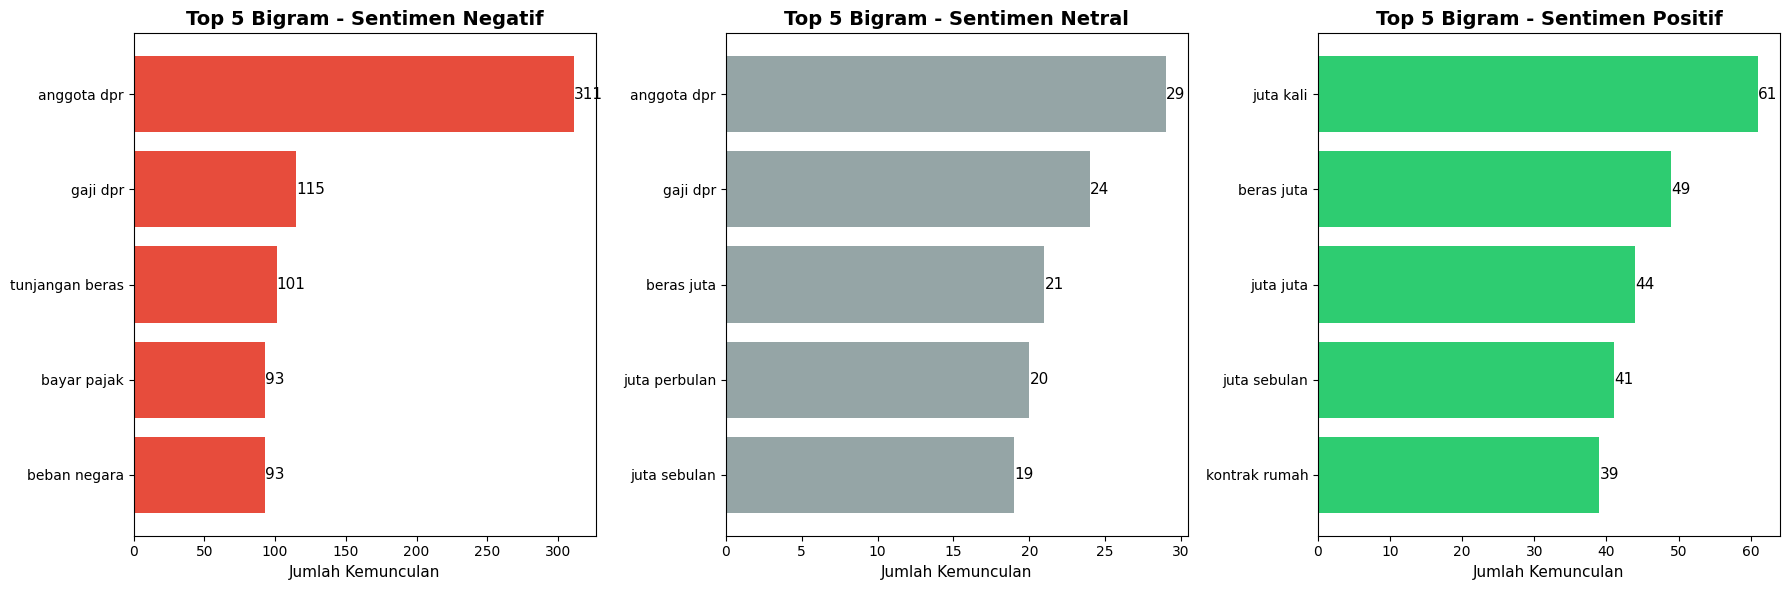

In [26]:
plot_bigrams_combined(
    [corpus_neg, corpus_neu, corpus_pos],
    ["Negatif", "Netral", "Positif"],
    ["#e74c3c", "#95a5a6", "#2ecc71"],
    stopwords=custom_stopwords
)

## frekuensi kata

In [27]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from collections import Counter

# Pisahkan dataset berdasarkan sentimen
sentimen_Neutral = data[data['Sentiment'] == 'Netral']['stopword removal'].str.cat(sep=' ')
sentimen_Negative = data[data['Sentiment'] == 'Negatif']['stopword removal'].str.cat(sep=' ')
sentimen_Positive = data[data['Sentiment'] == 'Positif']['stopword removal'].str.cat(sep=' ')

# Stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update([
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh'])

# Fungsi hitung frekuensi kata + tampilkan jumlah
def plot_word_freq(text, title, color):
    words = [w for w in text.split() if w not in stopwords]
    word_freq = Counter(words).most_common(10)  # ambil 10 kata teratas
    df_freq = pd.DataFrame(word_freq, columns=['Kata', 'Frekuensi'])

    plt.figure(figsize=(8,5))
    bars = plt.barh(df_freq['Kata'], df_freq['Frekuensi'], color=color)
    plt.gca().invert_yaxis()  # biar kata frekuensi tertinggi di atas
    plt.title(f"Top 10 Kata - Sentimen {title}", fontsize=14)
    plt.xlabel("Frekuensi")
    plt.ylabel("Kata")

    # Tambahkan label jumlah di ujung bar
    for bar in bars:
        plt.text(
            bar.get_width() + 0.2,  # posisi X sedikit ke kanan
            bar.get_y() + bar.get_height()/2,  # posisi Y di tengah bar
            str(int(bar.get_width())),  # nilai frekuensi
            va='center'
        )

    plt.show()

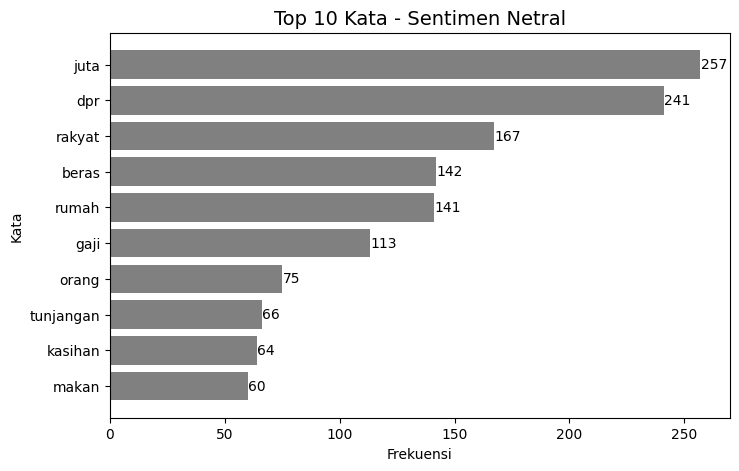

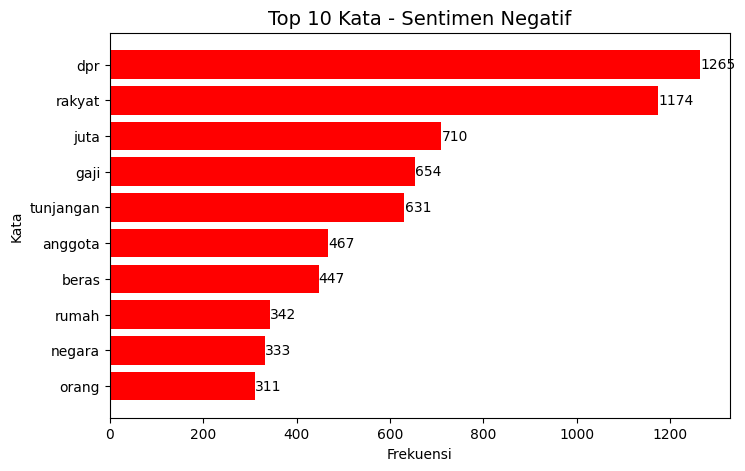

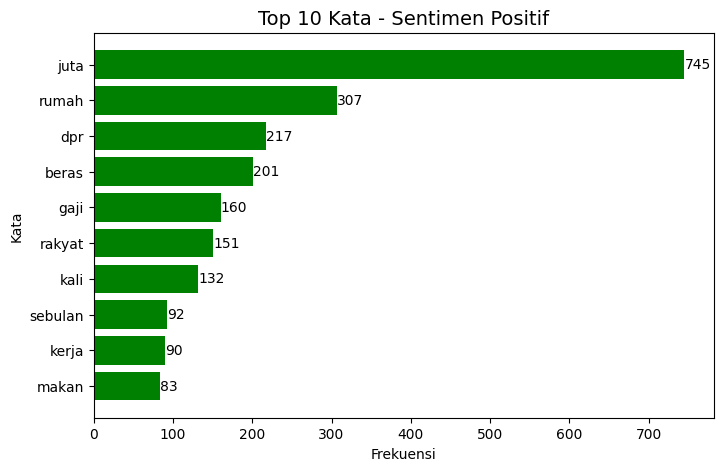

: 

In [ ]:
plot_word_freq(sentimen_Neutral, "Netral", "gray")
plot_word_freq(sentimen_Negative, "Negatif", "red")
plot_word_freq(sentimen_Positive, "Positif", "green")
